In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

H5_PATH = "../data/Galaxy10_DECals.h5"

with h5py.File(H5_PATH, "r") as f:
    print("Keys in file:", list(f.keys()))
    print("Images shape:", f["images"].shape)
    print("Images dtype:", f["images"].dtype)
    print("Labels shape:", f["ans"].shape)

Keys in file: ['ans', 'dec', 'images', 'pxscale', 'ra', 'redshift']
Images shape: (17736, 256, 256, 3)
Images dtype: uint8
Labels shape: (17736,)


In [2]:
with h5py.File(H5_PATH, "r") as f:
    labels = np.array(f["ans"])

class_names = [
    "0: disturbed",
    "1: merging",
    "2: round smooth",
    "3: in-between round smooth",
    "4: cigar-shaped smooth",
    "5: barred spiral",
    "6: unbarred tight spiral",
    "7: unbarred loose spiral",
    "8: edge-on without bulge",
    "9: edge-on with bulge",
]

counts = Counter(labels.tolist())
total = len(labels)

print(f"Total images: {total}\n")
for cls in range(10):
    n = counts[cls]
    pct = 100 * n / total
    print(f"{class_names[cls]:<35} {n:>5} ({pct:5.2f}%)")

Total images: 17736

0: disturbed                         1081 ( 6.09%)
1: merging                           1853 (10.45%)
2: round smooth                      2645 (14.91%)
3: in-between round smooth           2027 (11.43%)
4: cigar-shaped smooth                334 ( 1.88%)
5: barred spiral                     2043 (11.52%)
6: unbarred tight spiral             1829 (10.31%)
7: unbarred loose spiral             2628 (14.82%)
8: edge-on without bulge             1423 ( 8.02%)
9: edge-on with bulge                1873 (10.56%)


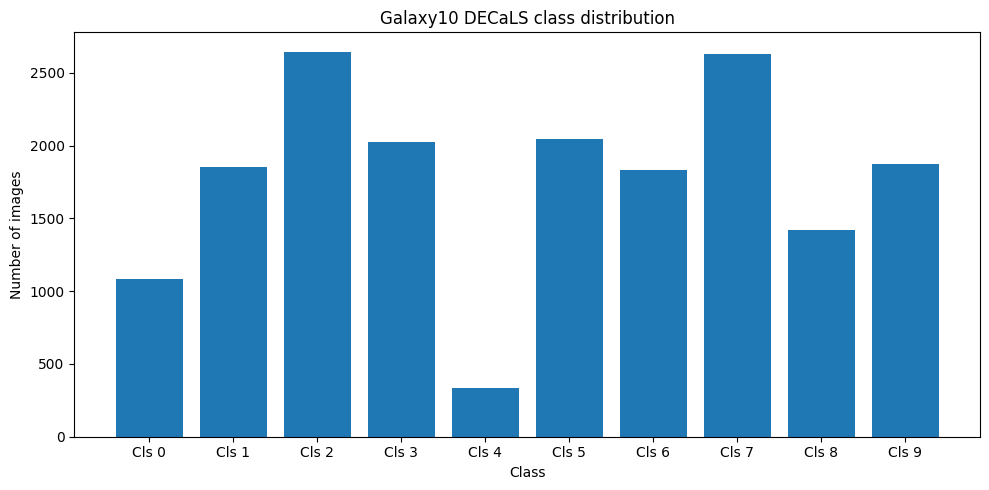

In [3]:
fig, ax = plt.subplots(figsize = (10, 5))
class_indices = list(range(10))
class_counts = [counts[c] for c in class_indices]

ax.bar(class_indices, class_counts)
ax.set_xticks(class_indices)
ax.set_xticklabels([f"Cls {i}" for i in class_indices], rotation=0)
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.set_title("Galaxy10 DECaLS class distribution")
plt.tight_layout()
plt.show()

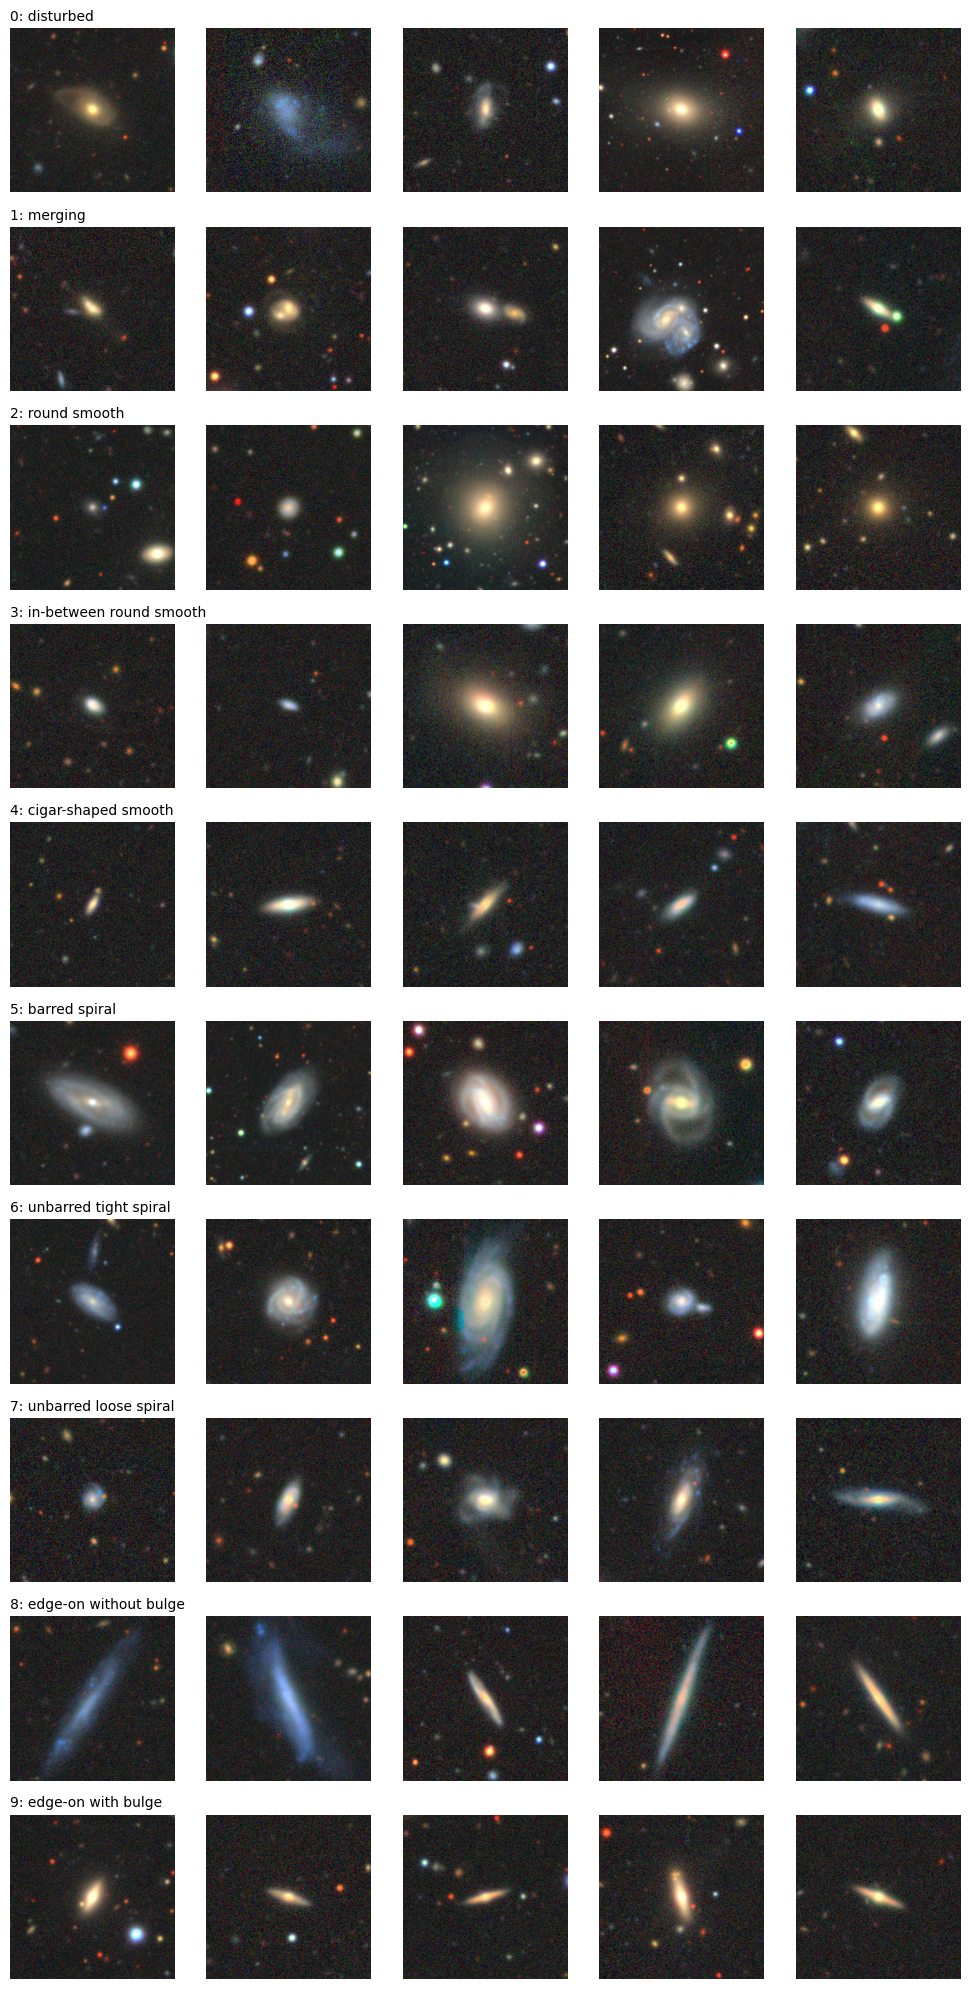

In [4]:
import random
random.seed(42)

# Find indicies for each class
indices_by_class = {c: np.where(labels == c)[0] for c in range(10)}

# Pick 5 random samples per class
samples_per_class = 5
fig, axes = plt.subplots(10, samples_per_class, figsize=(samples_per_class * 2, 20))

with h5py.File(H5_PATH, "r") as f:
    images = f["images"]

    for cls in range(10):
        chosen = random.sample(list(indices_by_class[cls]), samples_per_class)
        chosen_sorted = sorted(chosen)
        imgs = images[chosen_sorted]

        for i, img in enumerate(imgs):
            ax = axes[cls, i]
            ax.imshow(img)
            ax.axis("off")
            if i == 0:
                ax.set_title(class_names[cls], fontsize = 10, loc = "left")

plt.tight_layout()
plt.show()

In [5]:
with h5py.File(H5_PATH, "r") as f:
    sample = f["images"][:100]

print("Shape:", sample.shape)
print("Dtype:", sample.dtype)
print("Min:", sample.min())
print("Max:", sample.max())
print("Mean:", sample.mean())
print("Std:", sample.std())

Shape: (100, 256, 256, 3)
Dtype: uint8
Min: 0
Max: 255
Mean: 38.74404800415039
Std: 26.33288959498687


## EDA Summary

### Dataset

- 17,736 images, 256x256x3, uint8 in [0, 255]
- 10 morphology classes
- Pixel mean 38.7, much lower than natural images. Most of each frame is dark sky.

### Class distribution

- Significant imbalance, ratio ~8:1 between largest and smallest class.
- Largest: class 2 (round smooth) at 14.9%.
- Smallest: class 4 (cigar-shaped smooth) at 1.9%, ~334 images total.
- Class 4 will have only ~50 images in test set, so per-class metrics there will be noisy.

### Visual inspection

- Sampled 5 images from each of 10 classes. Labels look sensible.
- Genuinely ambiguous pairs: [list any you noticed, e.g. classes 2 vs 3, classes 6 vs 7]
- No obviously broken images in the sample.

### Design decisions for training

- Split: stratified 70/15/15 train/val/test by class label. Save indices to CSV for reproducibility.
- Class imbalance: use class-weighted cross entropy. Weights computed from inverse class frequency on the training split only.
- Augmentations: galaxies have no preferred orientation in the sky, so horizontal flip, vertical flip, and arbitrary rotation are all valid.
- Resize: centre crop 224 from 256 for both train and eval (avoid stretching).
- Normalisation: ImageNet mean and std, despite distribution mismatch, because pretrained backbone expects them.
- Backbone: ResNet50 pretrained on ImageNet, two-stage fine tuning.

### Known limitations

- Label noise from Galaxy Zoo crowdsourcing. The 55% agreement threshold helps but doesn't eliminate ambiguity.
- Class 4 (cigar-shaped) sample size will limit how well we can evaluate it.
- Not validated for production scientific use.

In [6]:
import sys
sys.path.append("../src")
 
from dataset import GalaxyDataset, load_split
from transforms import get_train_transform, get_eval_transform

# Load train split
train_indices = load_split("../data/splits.csv", "train")
print(f"Train indices: {len(train_indices)} (expected 12414)")

train_ds = GalaxyDataset(
    h5_path = "../data/Galaxy10_DECals.h5",
    indices = train_indices,
    transform = get_train_transform(),
)
print(f"Dataset length:  {len(train_ds)}")

img, label = train_ds[0]
print(f"Image type: {type(img).__name__}")
print(f"Image shape: {tuple(img.shape)}")
print(f"Image dtype: {img.dtype}")
print(f"Image min/max/mean: {img.min():.3f} / {img.max():.3f} / {img.mean():.3f}")
print(f"Label: {label} (class {label})")

Train indices: 12414 (expected 12414)
Dataset length:  12414
Image type: Tensor
Image shape: (3, 224, 224)
Image dtype: torch.float32
Image min/max/mean: -2.118 / 2.640 / -1.286
Label: 0 (class 0)


In [7]:
from torch.utils.data import DataLoader

loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    persistent_workers=True,
)

for batch_images, batch_labels in loader:
    print(f"Batch images: {tuple(batch_images.shape)} {batch_images.dtype}")
    print(f"Batch labels: {tuple(batch_labels.shape)} {batch_labels.dtype}")
    print(f"First 8 labels: {batch_labels[:8].tolist()}")
    break

Batch images: (32, 3, 224, 224) torch.float32
Batch labels: (32,) torch.int64
First 8 labels: [9, 7, 0, 7, 1, 9, 2, 0]


In [8]:
import torch
from model import build_model, freeze_backbone, unfreeze_layer4, count_trainable_params

# Build (this triggers a one-time ~100 MB weights download the first run)
model = build_model()

# Stage 1 sanity check
freeze_backbone(model)
trainable, total = count_trainable_params(model)
print(f"Stage 1: {trainable:>12,} trainable / {total:>12,} total "
      f"({100 * trainable / total:.3f}%)")

# Stage 2 sanity check
unfreeze_layer4(model)
trainable, total = count_trainable_params(model)
print(f"Stage 2: {trainable:>12,} trainable / {total:>12,} total "
      f"({100 * trainable / total:.3f}%)")

# Quick forward pass to make sure the architecture is wired correctly
model.eval()
x = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    y = model(x)
print(f"\nForward pass: input {tuple(x.shape)}, output {tuple(y.shape)}")

0.3%

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Zayn0/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


Stage 1:       20,490 trainable /   23,528,522 total (0.087%)
Stage 2:   14,985,226 trainable /   23,528,522 total (63.690%)

Forward pass: input (2, 3, 224, 224), output (2, 10)
